In [6]:
# Cell 1: Import libraries and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import re
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")


In [7]:
# Cell 2: Parse SPSS syntax file
def parse_spss_syntax(sps_file_path):
    """Parse SPSS syntax file to extract variable labels and value labels"""
    with open(sps_file_path, 'r', encoding='utf-8') as f:
        sps_content = f.read()
    
    # Extract variable labels
    variable_labels = {}
    var_label_pattern = r"VARIABLE LABELS\s+(\S+)\s+'([^']+)'"
    for match in re.finditer(var_label_pattern, sps_content):
        var_name = match.group(1)
        var_label = match.group(2)
        variable_labels[var_name] = var_label
    
    # Extract value labels
    value_labels = {}
    value_label_pattern = r"VALUE LABELS\s+(\S+)\s+((?:\s+\d+\s+'[^']+'\s*)+)\."
    
    for match in re.finditer(value_label_pattern, sps_content, re.MULTILINE):
        var_name = match.group(1)
        values_block = match.group(2)
        value_pairs = re.findall(r"(\d+)\s+'([^']+)'", values_block)
        value_labels[var_name] = {int(code): label.strip() for code, label in value_pairs}
    
    return variable_labels, value_labels

# Load your data
csv_file_path = 'Data/results.csv'  
sps_file_path = 'Data/syntax.sps'  # Update path

df = pd.read_csv(csv_file_path, delimiter=';', encoding='utf-8')
variable_labels, value_labels = parse_spss_syntax(sps_file_path)

print(f"Dataset shape: {df.shape}")
print(f"Found {len(variable_labels)} variable labels")
print(f"Found {len(value_labels)} variables with value labels")


Dataset shape: (24, 231)
Found 228 variable labels
Found 197 variables with value labels


In [8]:
# Cell 3: Data preparation for PCA
def prepare_pca_data_flexible(df, variable_labels, exclude_patterns=None, min_responses=5):
    """
    Prepare data for PCA with flexible handling of sub-questions
    
    Parameters:
    df: DataFrame with questionnaire data
    variable_labels: Dictionary of variable labels
    exclude_patterns: List of patterns to exclude from analysis
    min_responses: Minimum number of non-null responses required
    """
    
    # Default exclusions
    default_exclude = ['$submission_id', '$created', '$answer_time_ms', 'Org_name', 'Org_desc_other']
    if exclude_patterns is None:
        exclude_patterns = default_exclude
    else:
        exclude_patterns.extend(default_exclude)
    
    # Select numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # Remove excluded patterns
    pca_columns = []
    for col in numeric_cols:
        exclude = False
        for pattern in exclude_patterns:
            if pattern in col:
                exclude = True
                break
        if not exclude:
            pca_columns.append(col)
    
    # Filter by minimum responses (more flexible than 50% rule)
    valid_columns = []
    missing_info = {}
    
    for col in pca_columns:
        non_null_count = df[col].count()
        missing_count = df[col].isnull().sum()
        missing_info[col] = {
            'non_null': non_null_count,
            'missing': missing_count,
            'missing_pct': (missing_count / len(df)) * 100
        }
        
        if non_null_count >= min_responses:
            valid_columns.append(col)
    
    print(f"Selected {len(valid_columns)} variables for PCA analysis")
    print(f"Minimum responses threshold: {min_responses}")
    
    # Show missing data summary
    missing_df = pd.DataFrame(missing_info).T
    missing_df = missing_df.sort_values('missing_pct', ascending=False)
    
    return valid_columns, missing_df

# Prepare data
exclude_patterns = [
    '$submission_id', '$created', '$answer_time_ms', 
    'Org_name', 'Org_desc_other', '_desc', '_comments'
]

pca_columns, missing_summary = prepare_pca_data_flexible(
    df, variable_labels, exclude_patterns, min_responses=5
)

print("\nMissing data summary (top 10):")
print(missing_summary.head(10))



Selected 199 variables for PCA analysis
Minimum responses threshold: 5

Missing data summary (top 10):
                       non_null  missing  missing_pct
software_barrieres.7       13.0     11.0    45.833333
indicators_barriers.7      14.0     10.0    41.666667
software_satisfaction      23.0      1.0     4.166667
software_importance        23.0      1.0     4.166667
Org_type                   24.0      0.0     0.000000
Role_type.1                24.0      0.0     0.000000
Role_type.2                24.0      0.0     0.000000
Role_type.7                24.0      0.0     0.000000
Role_type.8                24.0      0.0     0.000000
experience_current         24.0      0.0     0.000000


In [9]:
# Cell 4: Handle missing values with conditional logic
def handle_missing_values_conditional(df, pca_columns):
    """
    Handle missing values considering conditional logic of questionnaire
    """
    df_pca = df[pca_columns].copy()
    
    # Strategy 1: For main questions (Yes/No), fill with 0 (No)
    yes_no_columns = [col for col in pca_columns if col in [
        'Role_type.1', 'Role_type.2', 'Role_type.3', 'Role_type.4', 'Role_type.5',
        'Role_type.6', 'Role_type.7', 'Role_type.8',
        'decision_type.1', 'decision_type.2', 'decision_type.3', 'decision_type.4',
        'decision_type.5', 'decision_type.6', 'decision_type.7',
        'analyze_type.1', 'analyze_type.2', 'analyze_type.3', 'analyze_type.4',
        'analyze_type.5', 'analyze_type.6',
        'simulation_type.1', 'simulation_type.2', 'simulation_type.3', 'simulation_type.4',
        'simulation_type.5', 'simulation_type.6', 'simulation_type.7', 'simulation_type.8'
    ]]
    
    # Fill Yes/No questions with 0 (assuming missing = No)
    for col in yes_no_columns:
        if col in df_pca.columns:
            df_pca[col] = df_pca[col].fillna(0)
    
    # Strategy 2: For sub-questions, use conditional mean imputation
    # If main question is 0 (No), sub-questions should be 0
    # If main question is 1 (Yes), use mean of those who answered Yes
    
    subquestion_mapping = {
        'decision_type.1': ['decision_type1_subtype.1', 'decision_type1_subtype.2', 
                           'decision_type1_subtype.3', 'decision_type1_subtype.4'],
        'decision_type.2': ['decision_type2_subtype.1', 'decision_type2_subtype.2', 
                           'decision_type2_subtype.3', 'decision_type2_subtype.4'],
        'decision_type.3': ['decision_type3_subtype.1', 'decision_type3_subtype.2', 
                           'decision_type3_subtype.3', 'decision_type3_subtype.4',
                           'decision_type3_subtype.5', 'decision_type3_subtype.6'],
        'decision_type.4': ['decision_type4_subtype.1', 'decision_type4_subtype.2', 
                           'decision_type4_subtype.3', 'decision_type4_subtype.4',
                           'decision_type4_subtype.5']
    }
    
    for main_q, sub_questions in subquestion_mapping.items():
        if main_q in df_pca.columns:
            for sub_q in sub_questions:
                if sub_q in df_pca.columns:
                    # If main question is No (0), sub-question should be 0
                    mask_no = df_pca[main_q] == 0
                    df_pca.loc[mask_no, sub_q] = 0
                    
                    # For those who answered Yes to main question, use mean imputation
                    mask_yes = df_pca[main_q] == 1
                    if mask_yes.sum() > 0:
                        mean_val = df_pca.loc[mask_yes, sub_q].mean()
                        if not np.isnan(mean_val):
                            df_pca.loc[mask_yes & df_pca[sub_q].isnull(), sub_q] = mean_val
    
    # Strategy 3: For remaining missing values, use median imputation
    imputer = SimpleImputer(strategy='median')
    remaining_cols = df_pca.columns[df_pca.isnull().any()].tolist()
    if remaining_cols:
        df_pca[remaining_cols] = imputer.fit_transform(df_pca[remaining_cols])
    
    return df_pca

# Apply missing value handling
df_pca_clean = handle_missing_values_conditional(df, pca_columns)

print(f"Data shape after cleaning: {df_pca_clean.shape}")
print(f"Remaining missing values: {df_pca_clean.isnull().sum().sum()}")


Data shape after cleaning: (24, 199)
Remaining missing values: 0


In [10]:
# Cell 5: Perform PCA Analysis
def perform_comprehensive_pca(df_pca, variable_labels, n_components=None):
    """
    Perform comprehensive PCA analysis with detailed outputs
    """
    # Standardize the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_pca)
    
    # Determine optimal number of components
    if n_components is None:
        # Use components that explain 80% of variance, but at least 5
        pca_full = PCA().fit(X_scaled)
        cumsum = np.cumsum(pca_full.explained_variance_ratio_)
        n_components = max(5, np.argmax(cumsum >= 0.8) + 1)
        n_components = min(n_components, len(df_pca.columns), len(df_pca))
    
    print(f"Using {n_components} components")
    
    # Perform PCA
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    
    # Calculate loadings
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    
    # Create comprehensive loadings DataFrame
    pc_names = [f'PC{i+1}' for i in range(n_components)]
    loadings_df = pd.DataFrame(
        loadings, 
        columns=pc_names, 
        index=df_pca.columns
    )
    
    # Add variable information
    loadings_df['Variable_Label'] = [
        variable_labels.get(col, col)[:80] + "..." if len(variable_labels.get(col, col)) > 80 
        else variable_labels.get(col, col) 
        for col in df_pca.columns
    ]
    
    # Calculate communalities (sum of squared loadings)
    loadings_df['Communality'] = (loadings_df[pc_names] ** 2).sum(axis=1)
    
    return pca, X_pca, loadings_df, scaler, X_scaled

# Perform PCA
pca, X_pca, loadings_df, scaler, X_scaled = perform_comprehensive_pca(
    df_pca_clean, variable_labels
)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Cumulative variance explained: {np.cumsum(pca.explained_variance_ratio_)}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.3f}")


Using 13 components
Explained variance ratio: [0.15182885 0.11258555 0.08058208 0.0651203  0.05988731 0.05856981
 0.05167051 0.05026741 0.04420219 0.0406132  0.03654381 0.0349369
 0.03280717]
Cumulative variance explained: [0.15182885 0.2644144  0.34499647 0.41011677 0.47000408 0.52857389
 0.5802444  0.63051181 0.674714   0.7153272  0.75187101 0.78680792
 0.81961508]
Total variance explained: 0.820


In [11]:
# Cell 6: Analyze Factor Loadings
def analyze_loadings_detailed(loadings_df, threshold=0.3):
    """
    Detailed analysis of factor loadings
    """
    pc_columns = [col for col in loadings_df.columns if col.startswith('PC')]
    n_components = len(pc_columns)
    
    print("=== DETAILED FACTOR LOADING ANALYSIS ===\n")
    
    # Analysis for each component
    for i, pc in enumerate(pc_columns):
        print(f"--- {pc} (Explains {pca.explained_variance_ratio_[i]:.1%} of variance) ---")
        
        # Get variables with high loadings
        high_loadings = loadings_df[abs(loadings_df[pc]) > threshold].copy()
        high_loadings = high_loadings.sort_values(pc, key=abs, ascending=False)
        
        if len(high_loadings) > 0:
            print(f"Variables with |loading| > {threshold}:")
            for idx, row in high_loadings.head(10).iterrows():
                loading_val = row[pc]
                direction = "+" if loading_val > 0 else "-"
                var_label = row['Variable_Label']
                print(f"  {direction} {idx:25s}: {loading_val:6.3f} - {var_label}")
        else:
            print(f"  No variables with |loading| > {threshold}")
        
        print()
    
    # Find variables that load highly on multiple components
    print("--- VARIABLES WITH HIGH CROSS-LOADINGS ---")
    cross_loading_vars = []
    for idx, row in loadings_df.iterrows():
        high_loadings_count = sum(abs(row[pc]) > threshold for pc in pc_columns)
        if high_loadings_count > 1:
            cross_loading_vars.append((idx, high_loadings_count, row))
    
    if cross_loading_vars:
        for var, count, row in sorted(cross_loading_vars, key=lambda x: x[1], reverse=True):
            loadings_str = ", ".join([f"{pc}:{row[pc]:.3f}" for pc in pc_columns if abs(row[pc]) > threshold])
            print(f"  {var}: {loadings_str}")
    else:
        print("  No variables with significant cross-loadings")
    
    return high_loadings

# Analyze loadings
high_loadings = analyze_loadings_detailed(loadings_df, threshold=0.3)


=== DETAILED FACTOR LOADING ANALYSIS ===

--- PC1 (Explains 15.2% of variance) ---
Variables with |loading| > 0.3:
  + analyze_type.2           :  0.787 - Hvilke av følgende analyser er relevant for din rolle Analyser for driftsplanleg...
  + analyze_type1_subtype.3  :  0.787 - Hvilke avbruddsanalyser er relevant /benyttes? Væravhengige avbrudd 
  + analyze_type2_subtype.2  :  0.771 - Hvilke av følgende analyser er relevant for driftsplanlegging og koordinering La...
  + analyze_type2_subtype1_subsubtype.2:  0.745 - Hvilke type driftstiltak analyseres Produksjonstilpasning
  + analyze_type2_subtype.1  :  0.738 - Hvilke av følgende analyser er relevant for driftsplanlegging og koordinering Im...
  + analyze_type2_subtype1_subsubtype.1:  0.738 - Hvilke type driftstiltak analyseres Lastbegrensning
  + analyze_type2_subtype1_subsubtype.3:  0.729 - Hvilke type driftstiltak analyseres Reaktiv effektregulering / Shunt-kobling (Sp...
  + analyze_type2_subtype1_subsubtype.4:  0.729 - Hvilke typ

In [12]:
# Cell 7: Variable Importance Analysis
def calculate_variable_importance_detailed(loadings_df, pca):
    """
    Calculate comprehensive variable importance metrics
    """
    pc_columns = [col for col in loadings_df.columns if col.startswith('PC')]
    
    # Method 1: Weighted by explained variance
    weighted_importance = np.zeros(len(loadings_df))
    for i, pc in enumerate(pc_columns):
        weighted_importance += np.abs(loadings_df[pc].values) * pca.explained_variance_ratio_[i]
    
    # Method 2: Sum of squared loadings (communalities)
    communalities = (loadings_df[pc_columns] ** 2).sum(axis=1)
    
    # Method 3: Maximum absolute loading
    max_loadings = loadings_df[pc_columns].abs().max(axis=1)
    
    # Create comprehensive importance DataFrame
    importance_df = pd.DataFrame({
        'Variable': loadings_df.index,
        'Weighted_Importance': weighted_importance,
        'Communality': communalities,
        'Max_Loading': max_loadings,
        'Variable_Label': loadings_df['Variable_Label']
    })
    
    # Add ranking columns
    importance_df['Weighted_Rank'] = importance_df['Weighted_Importance'].rank(ascending=False)
    importance_df['Communality_Rank'] = importance_df['Communality'].rank(ascending=False)
    importance_df['Max_Loading_Rank'] = importance_df['Max_Loading'].rank(ascending=False)
    
    return importance_df.sort_values('Weighted_Importance', ascending=False)

# Calculate importance
importance_df = calculate_variable_importance_detailed(loadings_df, pca)

print("=== TOP 15 MOST IMPORTANT VARIABLES ===")
for i, (idx, row) in enumerate(importance_df.head(15).iterrows()):
    print(f"{i+1:2d}. {row['Variable']:30s} ({row['Weighted_Importance']:.3f}) - {row['Variable_Label']}")


=== TOP 15 MOST IMPORTANT VARIABLES ===
 1. indicators_type.5              (0.245) - Forced Outage Rate (FOR)
 2. indicators_barriers.2          (0.237) - Datakvalitet (Dataene jeg trenger for å gjøre analysene er ikke tilgjengelig ell...
 3. indicators_type.12             (0.233) - Mean Time to Repair (MTTR)
 4. Role_type.2                    (0.230) - Hvilken hovedrolle har du i forbindelse med nettplanlegging, analyse eller drift...
 5. decision_type.1                (0.226) - Hvilke type beslutninger og arbeidsdprosesser er du involvert i der vurdering av...
 6. decision_type1_subtype.2       (0.226) - Hvilke av disse alternativene er aktuelle i forbindelse med tilknytninger og kun...
 7. indicators_type.1              (0.224) - Capacity Outage Probability Table (COPT)
 8. decision_type2_involvement.level (0.224) - Driftsplanlegging og/eller endringer av koblingsbildet
 9. analyze_type2_subtype.1        (0.224) - Hvilke av følgende analyser er relevant for driftsplanlegging og koor

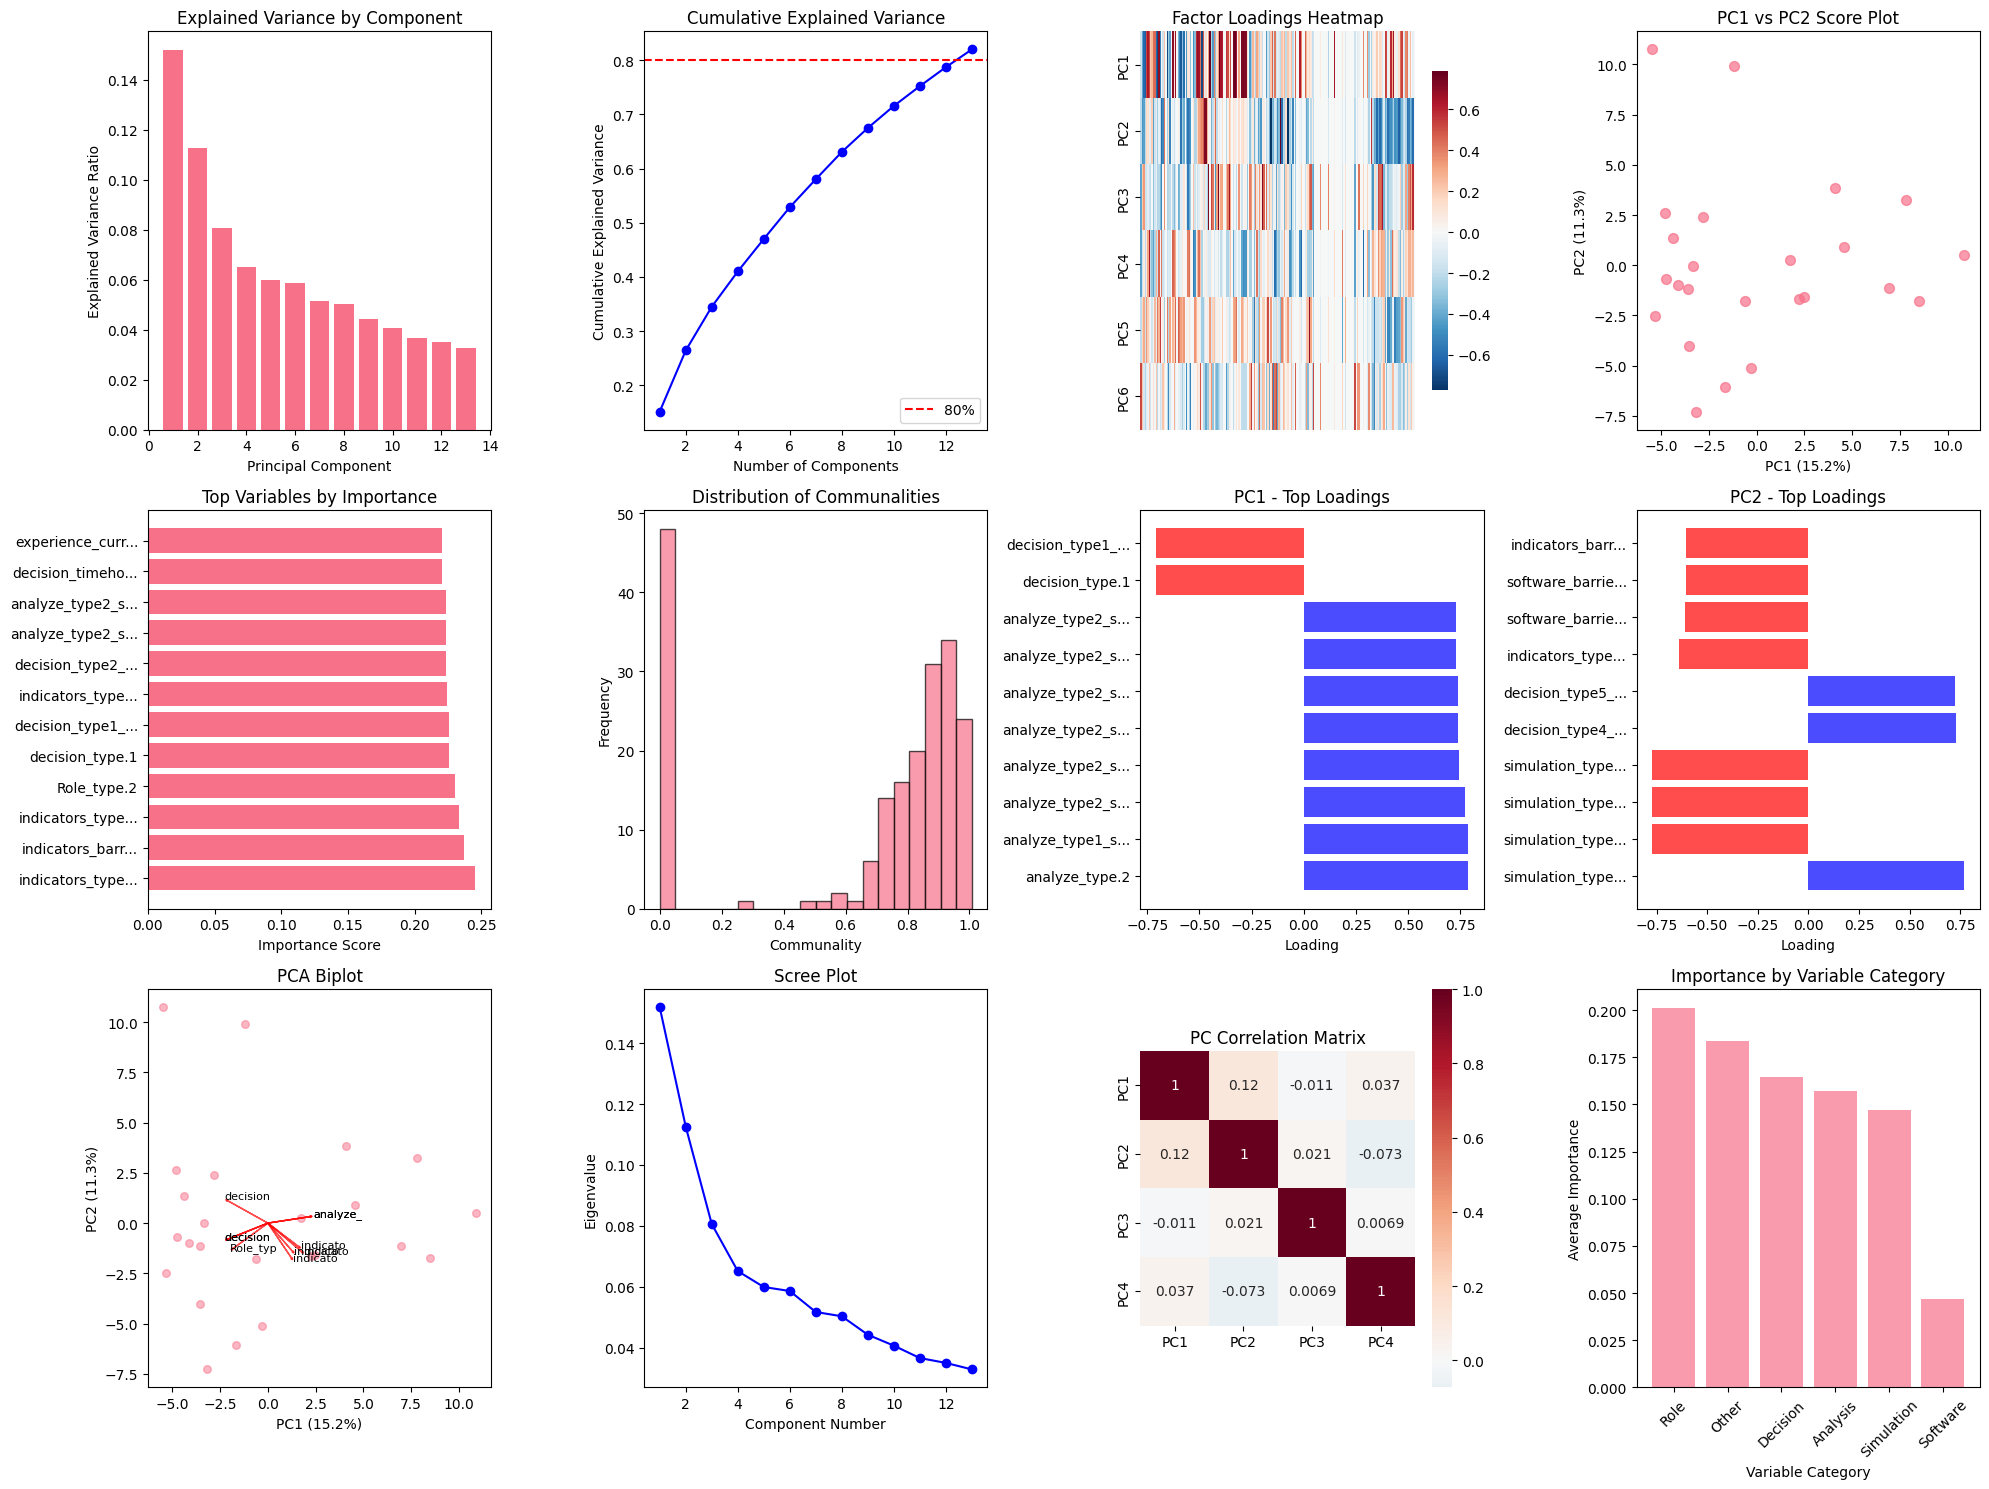

In [ ]:
# Cell 8: Create comprehensive visualizations
def create_pca_visualizations_comprehensive(pca, loadings_df, X_pca, importance_df):
    """
    Create comprehensive PCA visualizations
    """
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Explained Variance
    plt.subplot(3, 4, 1)
    plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
    plt.xlabel('Principal Component')
    plt.ylabel('Explained Variance Ratio')
    plt.title('Explained Variance by Component')
    
    # 2. Cumulative Explained Variance
    plt.subplot(3, 4, 2)
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    plt.plot(range(1, len(cumvar) + 1), cumvar, 'bo-')
    plt.axhline(y=0.8, color='r', linestyle='--', label='80%')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title('Cumulative Explained Variance')
    plt.legend()
    
    # 3. Loadings Heatmap
    plt.subplot(3, 4, 3)
    pc_cols = [col for col in loadings_df.columns if col.startswith('PC')][:6]  # First 6 PCs
    sns.heatmap(loadings_df[pc_cols].T, cmap='RdBu_r', center=0, 
                xticklabels=False, yticklabels=pc_cols, cbar_kws={'shrink': 0.8})
    plt.title('Factor Loadings Heatmap')
    
    # 4. PC1 vs PC2 Scatter
    plt.subplot(3, 4, 4)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, s=50)
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    plt.title('PC1 vs PC2 Score Plot')
    
    # 5. Variable Importance
    plt.subplot(3, 4, 5)
    top_vars = importance_df.head(12)
    plt.barh(range(len(top_vars)), top_vars['Weighted_Importance'])
    plt.yticks(range(len(top_vars)), [var[:15] + "..." if len(var) > 15 else var 
                                     for var in top_vars['Variable']])
    plt.xlabel('Importance Score')
    plt.title('Top Variables by Importance')
    
    # 6. Communalities
    plt.subplot(3, 4, 6)
    plt.hist(importance_df['Communality'], bins=20, alpha=0.7, edgecolor='black')
    plt.xlabel('Communality')
    plt.ylabel('Frequency')
    plt.title('Distribution of Communalities')
    
    # 7. PC1 Loadings
    plt.subplot(3, 4, 7)
    pc1_loadings = loadings_df['PC1'].sort_values(key=abs, ascending=False).head(10)
    colors = ['red' if x < 0 else 'blue' for x in pc1_loadings.values]
    plt.barh(range(len(pc1_loadings)), pc1_loadings.values, color=colors, alpha=0.7)
    plt.yticks(range(len(pc1_loadings)), [var[:15] + "..." if len(var) > 15 else var 
                                         for var in pc1_loadings.index])
    plt.xlabel('Loading')
    plt.title('PC1 - Top Loadings')
    
    # 8. PC2 Loadings
    plt.subplot(3, 4, 8)
    pc2_loadings = loadings_df['PC2'].sort_values(key=abs, ascending=False).head(10)
    colors = ['red' if x < 0 else 'blue' for x in pc2_loadings.values]
    plt.barh(range(len(pc2_loadings)), pc2_loadings.values, color=colors, alpha=0.7)
    plt.yticks(range(len(pc2_loadings)), [var[:15] + "..." if len(var) > 15 else var 
                                         for var in pc2_loadings.index])
    plt.xlabel('Loading')
    plt.title('PC2 - Top Loadings')
    
    # 9. Biplot (PC1 vs PC2)
    plt.subplot(3, 4, 9)
    # Plot data points
    plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=30)
    
    # Plot loading vectors for top variables
    top_loadings_idx = importance_df.head(10).index
    for var in top_loadings_idx:
        if var in loadings_df.index:
            pc1_load = loadings_df.loc[var, 'PC1']
            pc2_load = loadings_df.loc[var, 'PC2']
            plt.arrow(0, 0, pc1_load*3, pc2_load*3, 
                     head_width=0.1, head_length=0.1, fc='red', ec='red', alpha=0.7)
            plt.text(pc1_load*3.2, pc2_load*3.2, var[:8], fontsize=8)
    
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    plt.title('PCA Biplot')
    
    # 10. Scree Plot (Alternative view)
    plt.subplot(3, 4, 10)
    plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
             pca.explained_variance_ratio_, 'bo-')
    plt.xlabel('Component Number')
    plt.ylabel('Eigenvalue')
    plt.title('Scree Plot')
    
    # 11. Loading Matrix Correlation
    plt.subplot(3, 4, 11)
    pc_corr = loadings_df[pc_cols[:4]].corr()
    sns.heatmap(pc_corr, annot=True, cmap='RdBu_r', center=0, square=True)
    plt.title('PC Correlation Matrix')
    
    # 12. Variable Categories Analysis
    plt.subplot(3, 4, 12)
    # Categorize variables by type
    categories = {
        'Role': [col for col in loadings_df.index if col.startswith('Role_type')],
        'Decision': [col for col in loadings_df.index if col.startswith('decision_type')],
        'Analysis': [col for col in loadings_df.index if col.startswith('analyze_type')],
        'Simulation': [col for col in loadings_df.index if col.startswith('simulation_type')],
        'Software': [col for col in loadings_df.index if col.startswith('software_type')],
        'Other': [col for col in loadings_df.index if not any(col.startswith(prefix) 
                 for prefix in ['Role_type', 'decision_type', 'analyze_type', 'simulation_type', 'software_type'])]
    }
    
    category_importance = {}
    for cat, vars_list in categories.items():
        if vars_list:
            cat_importance = importance_df[importance_df['Variable'].isin(vars_list)]['Weighted_Importance'].mean()
            category_importance[cat] = cat_importance
    
    if category_importance:
        cats, importances = zip(*sorted(category_importance.items(), key=lambda x: x[1], reverse=True))
        plt.bar(cats, importances, alpha=0.7)
        plt.xlabel('Variable Category')
        plt.ylabel('Average Importance')
        plt.title('Importance by Variable Category')
        plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

# Create visualizations
create_pca_visualizations_comprehensive(pca, loadings_df, X_pca, importance_df)
